# SPI–SPI proof of concept (p90, 2026-08-24)

Can a common SPI–SPI representation organize multivariate time series generated by distinct dynamical mechanisms, despite variation in channel count $M$ and duration $T$?

The main figures show independent confirmation instances in a shared representation learned from development data. PCA is the linear reference; UMAP is the nonlinear visualization. A short appendix reports the prespecified cross-size validation.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from sklearn.decomposition import PCA
from umap import UMAP
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

ARTIFACT_ROOT = ROOT / "results/cross_mt_transfer_260824"
RESULT_PATH = ARTIFACT_ROOT / "confirmation-results.json"
COORDINATE_PATH = ARTIFACT_ROOT / "confirmation-coordinates.npz"
MANIFEST_PATH = ARTIFACT_ROOT / "development-manifest.json"

result = json.loads(RESULT_PATH.read_text())
manifest = json.loads(MANIFEST_PATH.read_text())
coordinates = np.load(COORDINATE_PATH, allow_pickle=False)
assert result["status"] == "confirmation_evaluated"
assert manifest["status"] == "development_frozen_confirmation_unseen"

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "legend.frameon": False,
})
print(f"development={manifest['rows']:,}; confirmation={result['rows']:,}; "
      f"schema={manifest['schema']['schema_sha256'][:12]}…")


/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


development=1,260; confirmation=2,520; schema=803abbe5885c…


## Representation and study design

For each dataset $X$, p90 computes $K=289$ multivariate interaction matrices (MPIs). The representation used in this completed experiment is

$$
z_{ab}(X)=\operatorname{corr}_{\mathrm{Pearson}}\!\left[
\operatorname{ut}\!\left(\frac{A_a+A_a^\top}{2}\right),
\operatorname{ut}\!\left(\frac{A_b+A_b^\top}{2}\right)
\right],\qquad a<b,
$$

giving exactly $\binom{289}{2}=41{,}616$ coordinates, independent of $M$ and $T$. This historical construction symmetrizes directed MPIs; it should therefore be read as the direction-discarding version of the SPI–SPI representation, not the newer ordered-off-diagonal contract.

The source corpus contains 14 classes, $M\in\{8,16,32\}$ and $T\in\{500,1000,2000\}$. `brownian-defect` is excluded from both embeddings below. Development instances are 0–9; confirmation instances are 10–29.

### Preprocessing

PySPI received the raw simulated channels: no per-channel z-scoring. In SPI–SPI space, features with at least 95% finite development values were retained, missing values were filled with their development medians, near-constant features were removed, and retained features were centred by their development means. They were **not individually variance-standardized**: every $z_{ab}$ is already a correlation on the same $[-1,1]$ scale, and standardization would give noisy low-variance pairs the same weight as stable high-variance pairs.

Covariance PCA reduces the retained features to 50 components before UMAP. This is useful because $p\gg n$ and the SPI–SPI coordinates are strongly redundant; it stabilizes and accelerates neighbourhood estimation. The frozen PCA50 was fitted on the complete 14-class development bank and retains 89.3% of its variance. The two UMAPs below exclude `brownian-defect` during fitting and display, but the inherited PCA basis was fitted before that exclusion.


### UMAP parameters

Edit these two dictionaries and rerun from this cell to explore either embedding. They are intentionally independent because the global and within-CML neighbourhood scales need not be identical.


In [2]:
INTER_CLASS_UMAP = dict(
    n_neighbors=30,
    min_dist=0.10,
    spread=1.0,
    metric="euclidean",
    random_state=260824,
)

INTRA_CML_UMAP = dict(
    n_neighbors=30,
    min_dist=0.10,
    spread=1.0,
    metric="euclidean",
    random_state=260824,
)


In [3]:
labels = coordinates["confirmation_y"].astype(str)
M = coordinates["confirmation_M"].astype(int)
T = coordinates["confirmation_T"].astype(int)
EXCLUDED_CLASS = "brownian-defect"
classes = np.unique(labels[labels != EXCLUDED_CLASS])
palette = dict(zip(classes, plt.colormaps["tab20"](np.linspace(0, 1, len(classes)))))

families = {
    "CML": ["chaotic-traveling-wave", "defect-turbulence", "fdstc", "frozen-chaos", "sti-i"],
    "noise": ["cauchy-noise", "gaussian-noise"],
    "Kuramoto": ["kuramoto_omega-fast", "kuramoto_omega-slow"],
    "VAR(1)": ["var-phi-0.2_cpl-0.4", "var-phi-0.2_cpl-0.8", "var-phi-0.95_cpl-0.4"],
    "wave": ["wave-1d"],
}
assert sorted(sum(families.values(), [])) == classes.tolist()

def scatter_classes(ax, xy, point_labels, class_order):
    for name in class_order:
        keep = point_labels == name
        color = palette[name]
        ax.scatter(
            xy[keep, 0], xy[keep, 1], s=17,
            facecolors=[to_rgba(color, .10)],
            edgecolors=[to_rgba(color, .42)],
            linewidths=.65, label=name, rasterized=True,
        )
    ax.set_box_aspect(1)
    ax.set(xticks=[], yticks=[])

# A separate within-CML map: fit on development CML rows, transform confirmation CML rows.
development_keys = coordinates["development_row_keys"].astype(str)
development_labels = np.asarray([key.split("|", 1)[0] for key in development_keys])
development_pca = coordinates["development_pca_sym"]
confirmation_pca = coordinates["confirmation_pca_sym"]

inter_dev = development_labels != EXCLUDED_CLASS
inter_confirmation = labels != EXCLUDED_CLASS
inter_pca_model = PCA(n_components=2).fit(development_pca[inter_dev])
inter_pca_xy = inter_pca_model.transform(confirmation_pca[inter_confirmation])
inter_mapper = UMAP(**INTER_CLASS_UMAP).fit(development_pca[inter_dev])
inter_xy = inter_mapper.transform(confirmation_pca[inter_confirmation])
inter_labels = labels[inter_confirmation]

cml_classes = families["CML"]
cml_dev = np.isin(development_labels, cml_classes)
cml_confirmation = np.isin(labels, cml_classes)
cml_pca_model = PCA(n_components=2).fit(development_pca[cml_dev])
cml_pca_xy = cml_pca_model.transform(confirmation_pca[cml_confirmation])
cml_mapper = UMAP(**INTRA_CML_UMAP).fit(development_pca[cml_dev])
cml_xy = cml_mapper.transform(confirmation_pca[cml_confirmation])
cml_labels = labels[cml_confirmation]


/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Two-scale organization

The left column compares 13 dynamical classes. The right column is fitted separately using only five CML regimes, resolving within-family structure compressed in the global map. Its fitted development subset has 450 rows: five regimes, nine $(M,T)$ cells and ten instances per cell. PCA provides the linear reference; UMAP shows nonlinear neighbourhood organization. Every projection is fitted on development rows and applied without refitting to the confirmation points shown. UMAP axes and inter-cluster distances have no direct physical scale.


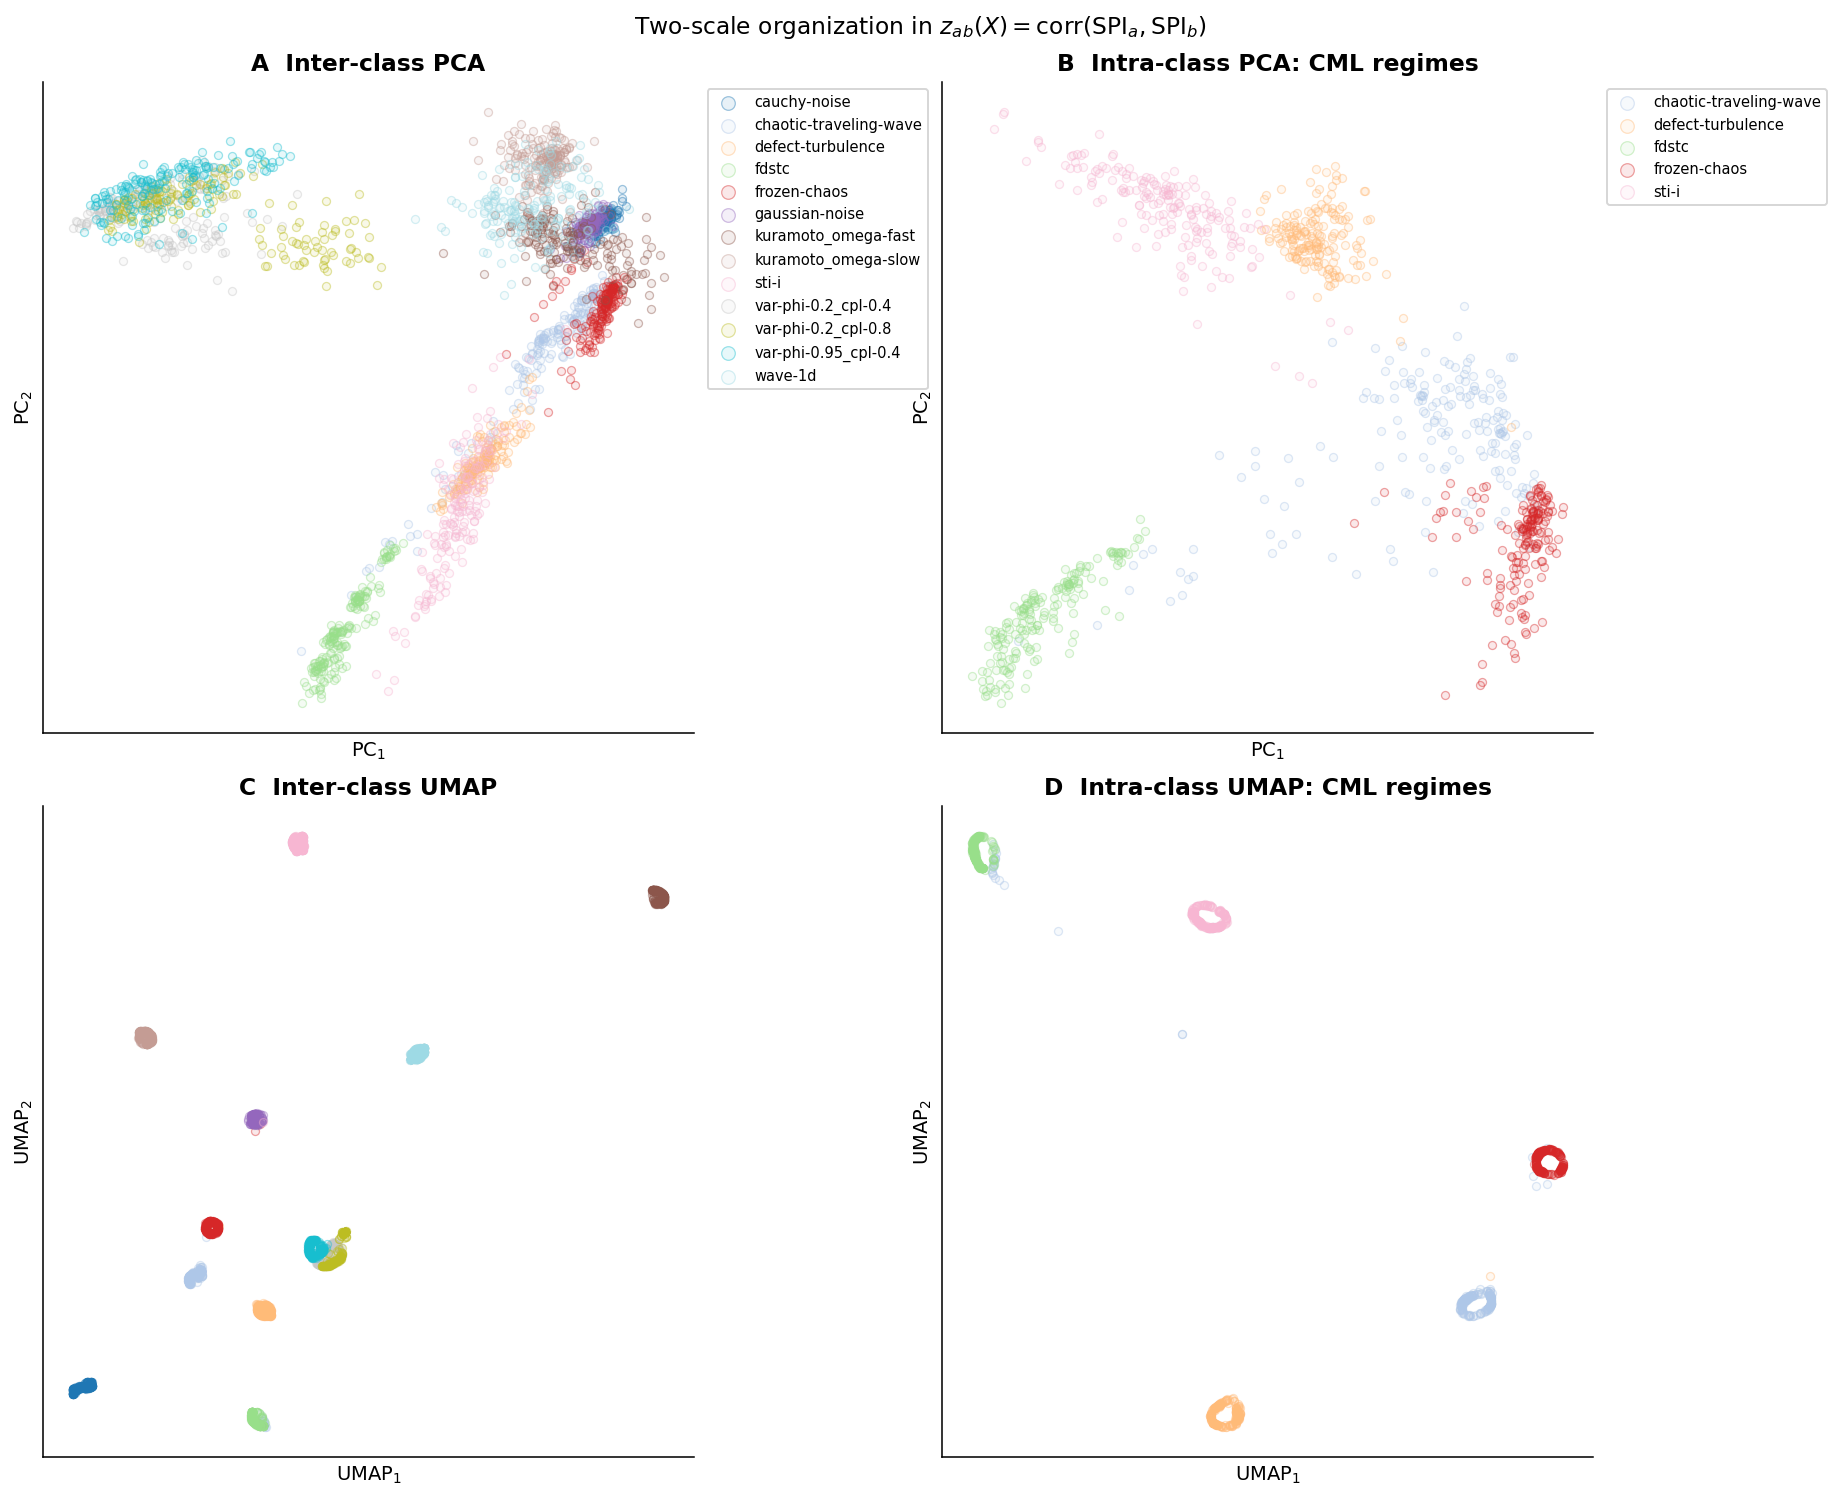

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12.8, 10.6), constrained_layout=True)
scatter_classes(axes[0, 0], inter_pca_xy, inter_labels, classes)
scatter_classes(axes[0, 1], cml_pca_xy, cml_labels, cml_classes)
scatter_classes(axes[1, 0], inter_xy, inter_labels, classes)
scatter_classes(axes[1, 1], cml_xy, cml_labels, cml_classes)

axes[0, 0].set_title(r"A  Inter-class PCA")
axes[0, 1].set_title(r"B  Intra-class PCA: CML regimes")
axes[1, 0].set_title(r"C  Inter-class UMAP")
axes[1, 1].set_title(r"D  Intra-class UMAP: CML regimes")
for ax in axes[0]:
    ax.set_xlabel(r"$\mathrm{PC}_1$")
    ax.set_ylabel(r"$\mathrm{PC}_2$")
for ax in axes[1]:
    ax.set_xlabel(r"$\mathrm{UMAP}_1$")
    ax.set_ylabel(r"$\mathrm{UMAP}_2$")
axes[0, 0].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=7.5,
                  frameon=True, markerscale=1.7)
axes[0, 1].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=7.5,
                  frameon=True, markerscale=1.7)
fig.suptitle(
    r"Two-scale organization in $z_{ab}(X)=\mathrm{corr}(\mathrm{SPI}_a,\mathrm{SPI}_b)$",
    fontsize=12,
)
plt.show()


## Appendix: quantitative cross-$M,T$ confirmation

This section checks rather than motivates the common-dimensional construction. Each fold excluded one complete $(M,T)$ cell during development and evaluated independent instances from that cell. “Hard” retrieval restricts candidate neighbours so that both $M$ and $T$ differ from the query. All filtering, imputation, scaling, PCA and models were fitted on development data only.


In [5]:
primary = result["results"]["sym"]
ba = primary["classification"]["balanced_accuracy"]
hard = primary["retrieval"]["both_M_and_T_changed"]["mean_average_precision"]
hard_null = primary["retrieval"]["both_M_and_T_changed"]["random_ranking_null"]["mean_average_precision"]
leak = primary["size_leakage"]["cell"]

display(Markdown(
    f"Held-out balanced accuracy: **{ba['estimate']:.3f}** "
    f"(95% CI {ba['confidence_interval'][0]:.3f}–{ba['confidence_interval'][1]:.3f}); "
    f"hard cross-size retrieval mAP: **{hard['estimate']:.3f}** "
    f"(95% CI {hard['confidence_interval'][0]:.3f}–{hard['confidence_interval'][1]:.3f}; "
    f"random-ranking expectation {hard_null:.3f}). "
    f"Joint $(M,T)$ remained decodable within class at {leak['estimate']:.3f} "
    f"(chance $1/9$), so the representation transfers across size but is not size-invariant."
))


Held-out balanced accuracy: **0.991** (95% CI 0.988–0.994); hard cross-size retrieval mAP: **0.818** (95% CI 0.814–0.821; random-ranking expectation 0.081). Joint $(M,T)$ remained decodable within class at 0.579 (chance $1/9$), so the representation transfers across size but is not size-invariant.

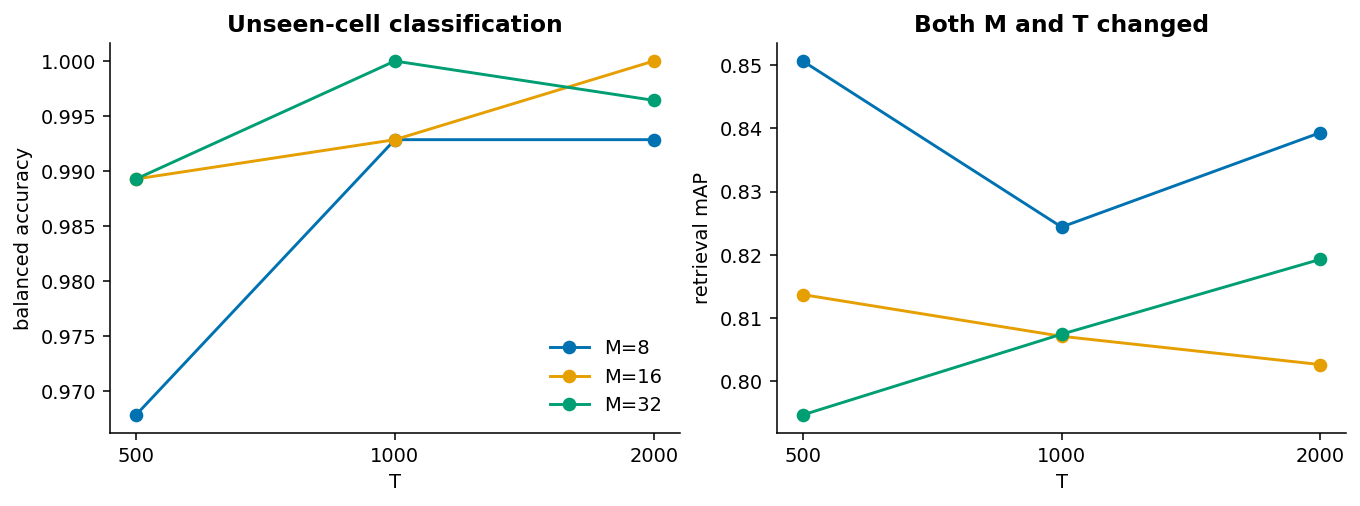

In [6]:
folds = primary["folds"]
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.5), constrained_layout=True)
for m, color in zip((8, 16, 32), ("#0072B2", "#E69F00", "#009E73")):
    cells = [f"M{m}_T{t}" for t in (500, 1000, 2000)]
    axes[0].plot((500, 1000, 2000),
                 [folds[cell]["balanced_accuracy"] for cell in cells],
                 "-o", color=color, label=f"M={m}")
    axes[1].plot((500, 1000, 2000),
                 [folds[cell]["hard_mean_average_precision"] for cell in cells],
                 "-o", color=color, label=f"M={m}")
axes[0].set(title="Unseen-cell classification", ylabel="balanced accuracy")
axes[1].set(title="Both M and T changed", ylabel="retrieval mAP")
for ax in axes:
    ax.set(xlabel="T", xscale="log", xticks=(500, 1000, 2000))
    ax.set_xticklabels(("500", "1000", "2000"))
    ax.minorticks_off()
axes[0].legend()
plt.show()


### Interpretation boundary

The figures support a common feature space with strong held-out class organization across the tested observation sizes. They do not establish strict invariance to $M$ or $T$, causal identification of a generating mechanism, or superiority to every alternative representation. The completed artifact also discards MPI direction; the ordered-off-diagonal p90 representation requires a separate reconstruction from the saved MPI matrices, not a new pyspi run.


## Data locations

**Gadi**

- Raw confirmation MTS and MPI artifacts: `/g/data/ql44/we2614/mts-spi-data-v2/embeddings/cross_mt_confirmation_260824/`
- Full confirmation feature bank: `/scratch/ql44/we2614/spi-spi-cross-mt-260824/confirmation.npz`
- Current 900-row development/proof bank: `/scratch/ql44/we2614/spi-spi-direction-v2/proof.npz`
- Four additional CML development classes: `/scratch/ql44/we2614/spi-spi-cross-mt-260824/cml-development.npz`

**Local compact artifacts**

- `results/cross_mt_transfer_260824/confirmation-coordinates.npz`
- `results/cross_mt_transfer_260824/confirmation-results.json`
- `results/cross_mt_transfer_260824/development-manifest.json`

The frozen internal study paths retain `cross_mt_transfer_260824` because they are bound into completed manifests and provenance. The notebook is the user-facing `proof_p90_260824` presentation of those data.
